<a href="https://colab.research.google.com/github/Krishna-97/part-2-cnn-computer-vision/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part 2: Computer Vision Problem Formulation and CNN Prototype**



In [1]:
requirements_content = """
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.2.0
tensorflow>=2.12.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_content.strip())

print("requirements.txt has been created!")

requirements.txt has been created!


## Task 1: Problem Identification
The dataset represents an **Image Classification** problem.




*   **Reasoning:** The goal is to categorize an entire image into a single, discrete label `(normal, scratch, dent, or stain)`. Unlike object detection, which would require bounding boxes around specific defects, or segmentation, which would require pixel-level masks, this task focuses on identifying the overall state of the product surface.




## Task 2: Dataset Exploration

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
# ====================
# Extract Zip Files
# =====================
ZIP_PATH = 'images.zip'
EXTRACT_PATH = 'dataset'
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print('Dataset extracted Successfully')
# ======================
# Load Label.csv
# =======================
df = pd.read_csv('labels.csv')
print('\n Label Dataset Preview :')
print(df.head())







Dataset extracted Successfully

 Label Dataset Preview :
                       filename   class
0  images/normal/normal_001.png  normal
1  images/normal/normal_002.png  normal
2  images/normal/normal_003.png  normal
3  images/normal/normal_004.png  normal
4  images/normal/normal_005.png  normal


*Dataset Information*

In [3]:
print('\n Dataset Shape:')
print(df.shape)
print('\n Class Distribution:')
print(df['class'].value_counts())



 Dataset Shape:
(480, 2)

 Class Distribution:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


## Task 3: Image Preprocessing
*VISUALIZE SAMPLE IMAGES*

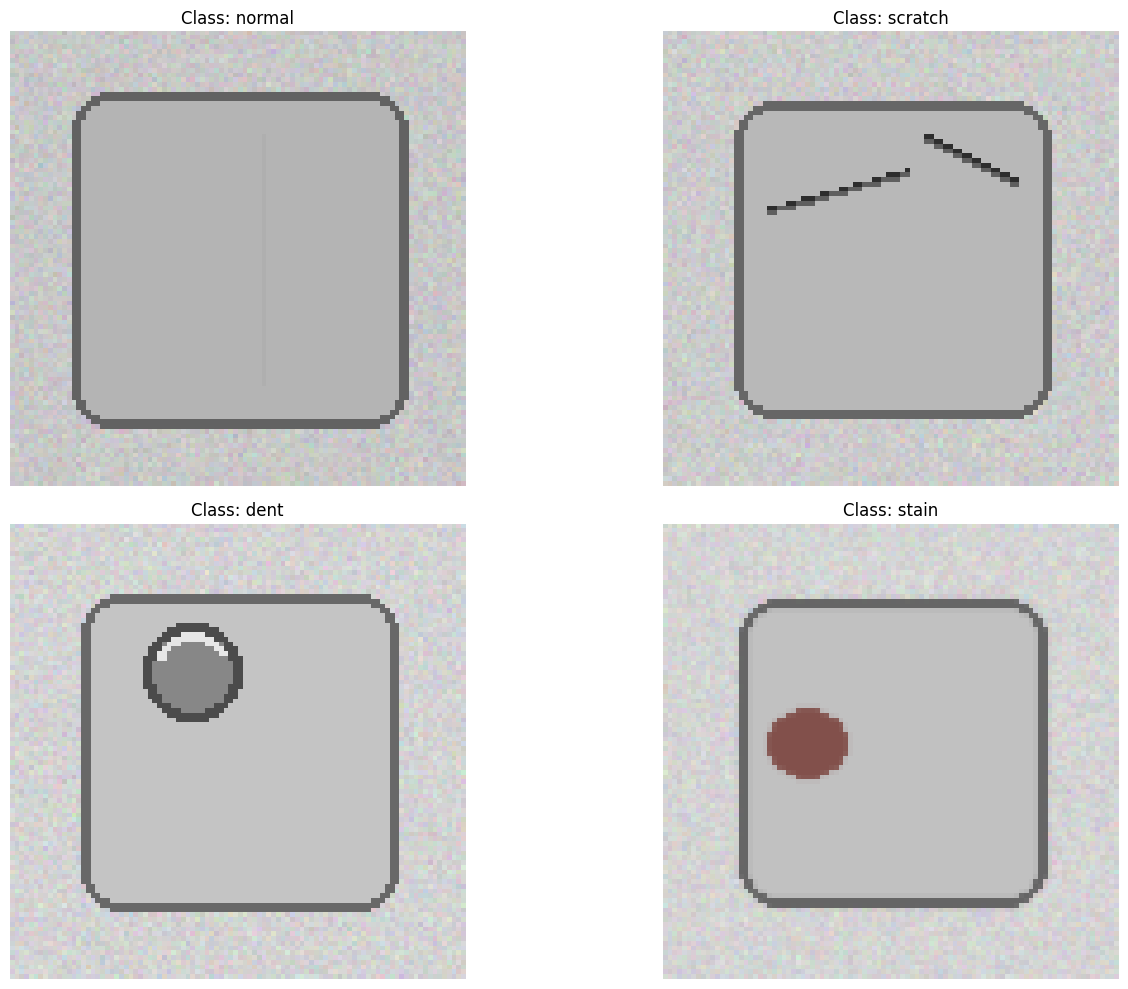

In [4]:
IMAGE_FOLDER = os.path.join(EXTRACT_PATH)
classes = df['class'].unique()
plt.figure(figsize=(15, 10))

for i,cls in enumerate(classes):
  sample_row = df[df['class'] == cls].iloc[0]
  image_path = os.path.join(IMAGE_FOLDER, sample_row['filename'])
  image = Image.open(image_path)
  plt.subplot(2, 2, i+1)
  plt.imshow(image)
  plt.title(f'Class: {cls}')
  plt.axis('off')

plt.tight_layout()
plt.show()

*IMAGE DIMENSIONS ANALYSIS*

In [5]:
image_sizes = []
for image_path in df['filename']:
    image_path = os.path.join(IMAGE_FOLDER, image_path)

    try:
        image = Image.open(image_path)
        image_sizes.append(image.size)
    except:
        pass
print('\nSample Image Sizes :')
print(image_sizes[:10])



Sample Image Sizes :
[(96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96)]


*TRAIN & TEST SPLIT*

In [6]:
from sklearn.model_selection import train_test_split

train_df,test_df = train_test_split(df, test_size=0.2, random_state=42,stratify=df['class'])
print('Training Samples :',len(train_df))
print('Testing Samples :',len(test_df))



Training Samples : 384
Testing Samples : 96


*IMAGE PREPROCESSING*

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG_HEIGHT =128
IMG_WIDTH = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # Added validation_split
)

test_datagen = ImageDataGenerator(rescale=1./255)

*TEST GENERATOR*

In [8]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=IMAGE_FOLDER,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset = 'training'
)

Found 308 validated image filenames belonging to 4 classes.


*VALIDATION GENERATOR*

In [9]:
validation_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=IMAGE_FOLDER,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset = 'validation'
)

Found 76 validated image filenames belonging to 4 classes.


*TEST GENERATOR*

In [10]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=IMAGE_FOLDER,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 96 validated image filenames belonging to 4 classes.


## Task 4: CNN Model Creation

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
model = Sequential()
# =======================
# FIRST CONVOLUTION BLOCK
# =======================
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# =========================
# SECOND CONVOLUTION BLOCK
# ==========================
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# =========================
# THIRD CONVOLUTION BLOCK
# =========================
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# ==============
# FLATTEN LAYER
# ===============
model.add(Flatten())

# ==============
# DENSE LAYERS
# ===============
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# ==============
# OUTPUT LAYER
# ==============
model.add(Dense(4, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ===============
# COMPILE MODEL
# ================
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# =================
# MODEL SUMMARY
# =================
print('\nCNN Model Summary :')
model.summary()
# ====================
# EARLY STOPPING
# ====================
early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



CNN Model Summary :


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,052 (12.61 MB)

 Trainable params: 3,305,604 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

## Task 5: Model Training and Evaluation

*MODEL TRAINING*

In [12]:
EPOCHS = 15
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.2890 - loss: 7.1546 - val_accuracy: 0.2632 - val_loss: 1.4125
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5422 - loss: 2.2423 - val_accuracy: 0.3158 - val_loss: 6.1588
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6623 - loss: 1.0488 - val_accuracy: 0.3158 - val_loss: 25.3981
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6591 - loss: 0.8308 - val_accuracy: 0.3158 - val_loss: 44.0186
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.6591 - loss: 0.8129 - val_accuracy: 0.3158 - val_loss: 56.4616
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7500 - loss: 0.7267 - val_accuracy: 0.3158 - val_loss: 63.8326
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


*SAVE THE MODEL*

In [13]:
model.save('cnn_model.h5')
print('\nMODEL SAVED SUCCESSFULLY')


MODEL SAVED SUCCESSFULLY


*PLOT TRAINING ACCURACY*

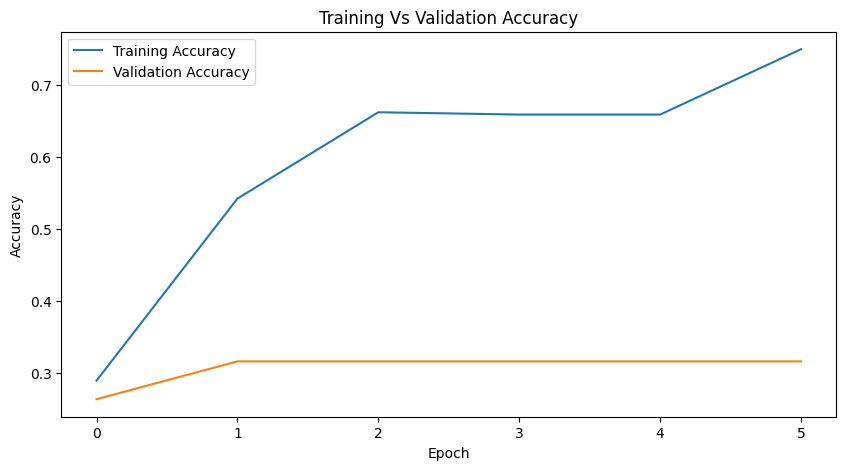

In [14]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Vs Validation Accuracy')
plt.legend()

plt.savefig('accuracy.png')
plt.show()

*PLOT TRAINING LOSS*

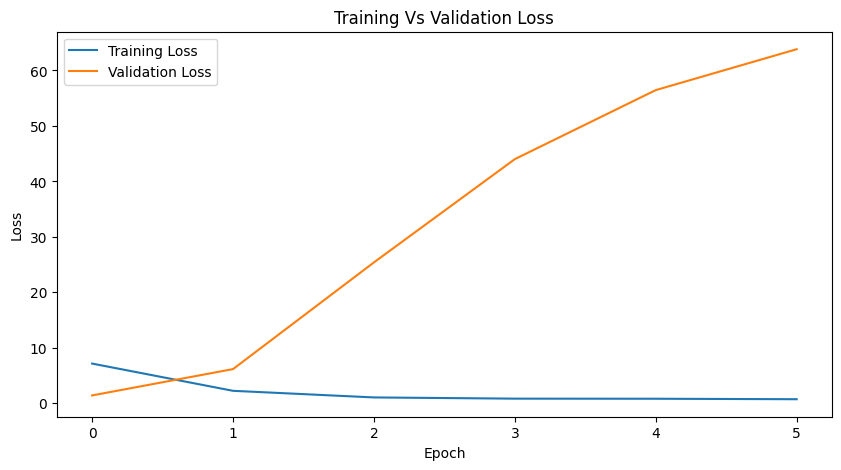

In [15]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Vs Validation Loss')
plt.legend()

plt.savefig('loss_curve.png')
plt.show()

*MODEL EVALUATION*

In [16]:
loss, accuracy = model.evaluate(test_generator)
print(f'\nTest Loss :',loss)
print(f'Test Accuracy :',accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 519ms/step - accuracy: 0.2500 - loss: 1.4279

Test Loss : 1.4278610944747925
Test Accuracy : 0.25


*PREDICTIONS*

In [17]:
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step


*CLASSIFICATION REPORT*

In [19]:
from sklearn.metrics import classification_report
print('\nClassification Report :')
print(classification_report(true_classes, predicted_classes, target_names=class_labels))


Classification Report :
              precision    recall  f1-score   support

        dent       0.00      0.00      0.00        24
      normal       0.00      0.00      0.00        24
     scratch       0.25      1.00      0.40        24
       stain       0.00      0.00      0.00        24

    accuracy                           0.25        96
   macro avg       0.06      0.25      0.10        96
weighted avg       0.06      0.25      0.10        96



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


*CONFUSION MATRIX*

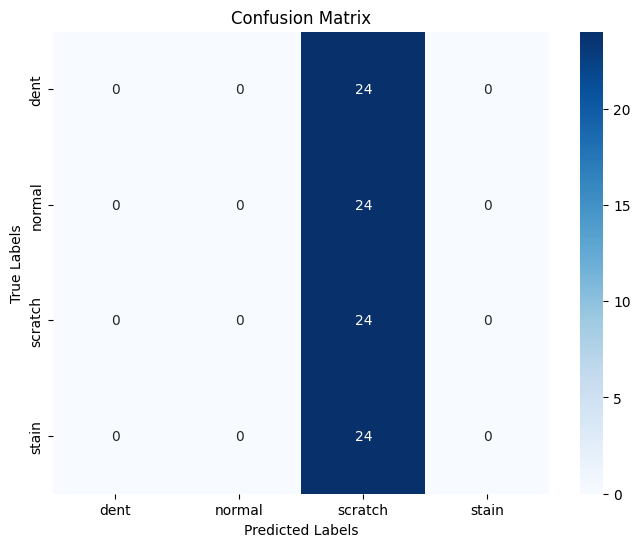

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
conf_matrix = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')

plt.savefig('confusion_matrix.png')
plt.show()

*SAMPLE PREDICTIONS*

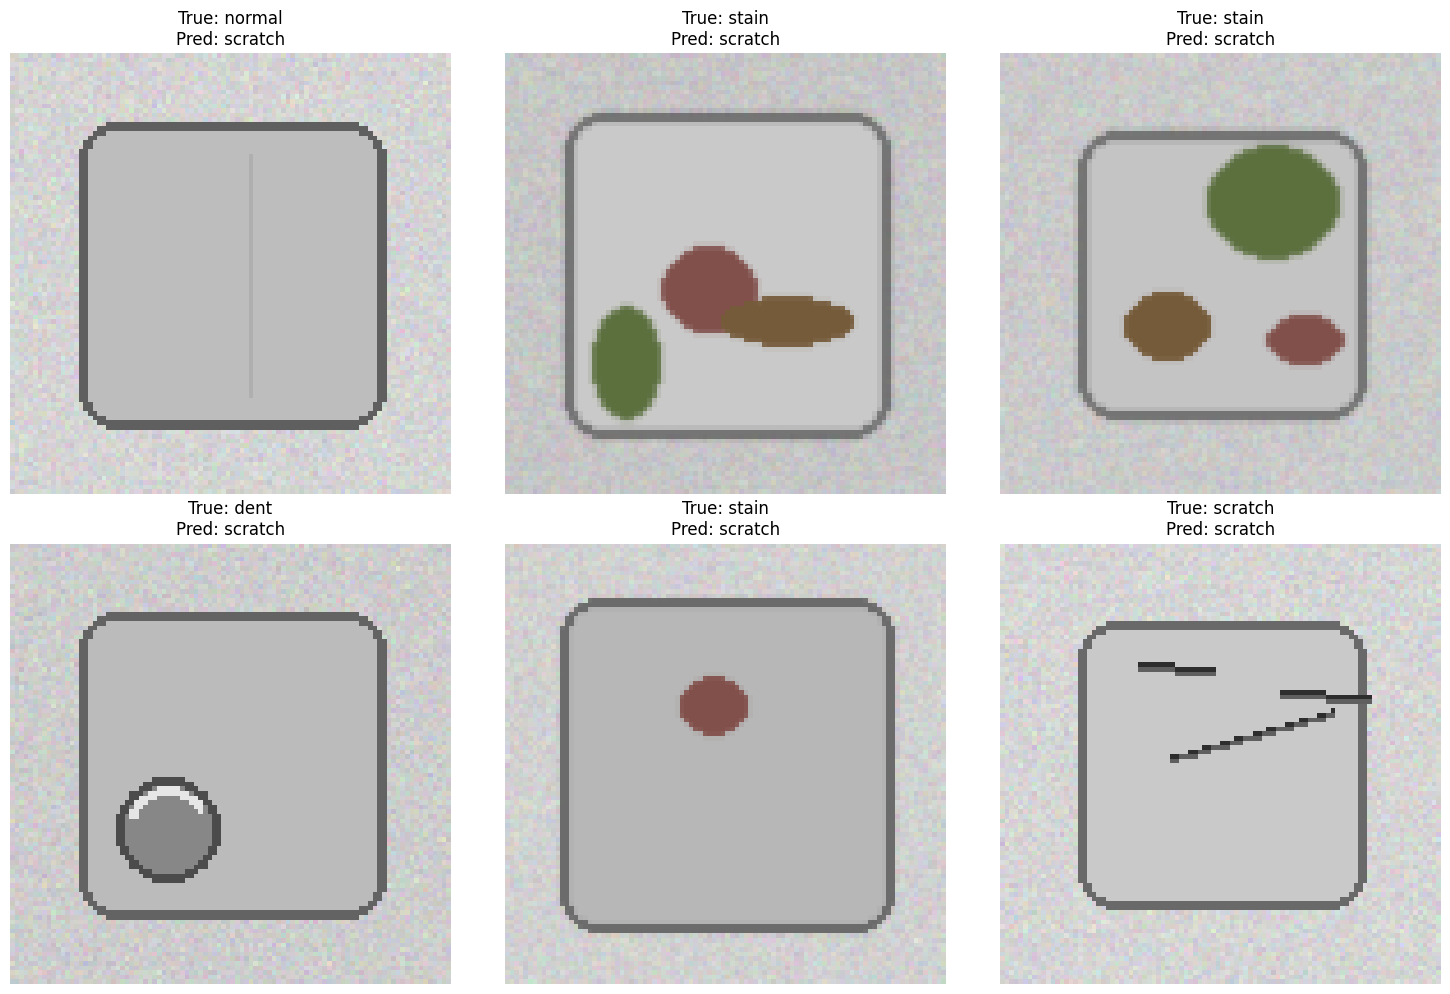

In [21]:
sample_images = df.sample(6,random_state=42)
plt.figure(figsize=(15, 10))

for i,(_,row) in enumerate(sample_images.iterrows()):
    image_path = os.path.join(IMAGE_FOLDER,row['filename'])
    img = Image.open(image_path).convert('RGB')
    img_resized = image.resize((IMG_HEIGHT, IMG_WIDTH))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(prediction)
    predicted_label = class_labels[np.argmax(prediction)]

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f'True: {row["class"]}\nPred: {predicted_label}')
    plt.axis('off')

plt.tight_layout()

plt.savefig('sample_predictions.png')
plt.show()

##Task 6: CNN Concept Explanation:


*   **What is convolution?** It is a mathematical operation where a small filter (kernel) slides across the image to create a `feature map, highlighting specific patterns like lines or curves`.
*   **Why is pooling used?** Pooling (usually Max Pooling) downsamples the feature map. This reduces the number of parameters the model needs to learn and makes the detection of features invariant to small shifts or distortions.
*   **Why ReLU?** The Rectified Linear Unit `($f(x) = \max(0, x)$)` is used because it allows the model to learn faster by alleviating the "vanishing gradient" problem and adding non-linearity.
*  **Why CNNs over Feed-Forward Networks?** Regular networks treat images as a flat list of pixels, losing spatial context. CNNs preserve the 2D relationship between pixels, making them significantly more efficient at recognizing visual patterns.


## Task 7: Business Use Case Mapping:

**Domain: Manufacturing**

This specific solution maps directly to ***Automated Quality Inspection***.



*   **Application:** In a high-speed production line (e.g., smartphone screens or automotive body panels), this CNN can replace manual human inspection.
*   **Impact:** It provides *24/7 monitoring, reduces human error caused by fatigue*, and categorizes defects instantly to help engineers identify if a specific machine in the factory is malfunctioning `(e.g., a "dent" suggests a mechanical strike, while a "stain" suggests a chemical leak)`.





